In [7]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from sklearn.model_selection import train_test_split 

from src.data_processing import clean_text
from src.bag_of_words import NumpyBagOfWords
from src.hyperopt import build_grid

from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer
from src.models_numpy.dnn.activation import ReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.optimizer import SGD

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(df['Label'].unique())}
df['label_id'] = df['Label'].map(label_map)

df['text_clean'] = df['Text'].apply(clean_text)

X_train, X_val, y_train, y_val = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42
)

param_grid_dnn = {
    'max_words': [2000, 3000, 3500],
    'hidden_neurons': [64, 128, 164],
    'learning_rate': [0.05, 0.1],
    'epochs': [200, 250]
}

resultados_dnn = []

print("=== A Iniciar Grid Search: DNN ===")
for params in build_grid(param_grid_dnn):
    print(f"\nA testar: {params}")
    inicio = time.time()

    num_classes = len(label_map)
    y_train_oh = np.eye(num_classes)[y_train.values]
    y_val_oh = np.eye(num_classes)[y_val.values]
    
    bow = NumpyBagOfWords(max_words=params['max_words'])
    X_tr = bow.fit_transform(X_train)
    X_te = bow.transform(X_val)
    
    model = NeuralNetwork()
    model.add(DenseLayer(input_size=params['max_words'], output_size=params['hidden_neurons']))
    model.add(ReLUActivation())
    model.add(DenseLayer(input_size=params['hidden_neurons'], output_size=6))
    model.add(SoftmaxActivation())
    
    model.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=params['learning_rate']))
    
    history = model.fit(X_tr, y_train_oh, epochs=params['epochs'], val_data=(X_te, y_val_oh))
    
    val_acc_final = history['val_acc'][-1]
    val_loss_final = history['val_loss'][-1]
    tempo_gasto = time.time() - inicio
    
    resultados_dnn.append({
        'Max Words': params['max_words'],
        'Hidden Neurons': params['hidden_neurons'],
        'Learning Rate': params['learning_rate'],
        'Val Accuracy': val_acc_final,
        'Val Loss': val_loss_final,
        'Tempo (s)': round(tempo_gasto, 1)
    })
    print(f" -> Val Acc: {val_acc_final:.4f} | Tempo: {tempo_gasto:.1f}s")

df_grid_dnn = pd.DataFrame(resultados_dnn).sort_values(by='Val Accuracy', ascending=False)
display(df_grid_dnn)

=== A Iniciar Grid Search: DNN ===

A testar: {'max_words': 2000, 'hidden_neurons': 64, 'learning_rate': 0.05, 'epochs': 200}
Epoch 10/200 | Loss: 0.6566 Acc: 0.7502 | Val Loss: 0.6864 Val Acc: 0.7296
Epoch 20/200 | Loss: 0.3091 Acc: 0.9046 | Val Loss: 0.4000 Val Acc: 0.8648
Epoch 30/200 | Loss: 0.1718 Acc: 0.9516 | Val Loss: 0.2977 Val Acc: 0.9018
Epoch 40/200 | Loss: 0.1088 Acc: 0.9740 | Val Loss: 0.2550 Val Acc: 0.9125
Epoch 50/200 | Loss: 0.0737 Acc: 0.9871 | Val Loss: 0.2327 Val Acc: 0.9270
Epoch 60/200 | Loss: 0.0527 Acc: 0.9929 | Val Loss: 0.2230 Val Acc: 0.9309
Epoch 70/200 | Loss: 0.0399 Acc: 0.9961 | Val Loss: 0.2171 Val Acc: 0.9348
Epoch 80/200 | Loss: 0.0314 Acc: 0.9981 | Val Loss: 0.2136 Val Acc: 0.9368
Epoch 90/200 | Loss: 0.0255 Acc: 0.9985 | Val Loss: 0.2121 Val Acc: 0.9387
Epoch 100/200 | Loss: 0.0213 Acc: 0.9988 | Val Loss: 0.2118 Val Acc: 0.9397


KeyboardInterrupt: 

A treinar o Modelo DNN Final...
Epoch 10/150 | Loss: 0.5818 Acc: 0.7987 | Val Loss: 0.5989 Val Acc: 0.7772
Epoch 20/150 | Loss: 0.2680 Acc: 0.9199 | Val Loss: 0.3651 Val Acc: 0.8774
Epoch 30/150 | Loss: 0.1420 Acc: 0.9642 | Val Loss: 0.2657 Val Acc: 0.9144
Epoch 40/150 | Loss: 0.0885 Acc: 0.9834 | Val Loss: 0.2241 Val Acc: 0.9261
Epoch 50/150 | Loss: 0.0593 Acc: 0.9937 | Val Loss: 0.2061 Val Acc: 0.9309
Epoch 60/150 | Loss: 0.0424 Acc: 0.9963 | Val Loss: 0.1983 Val Acc: 0.9348
Epoch 70/150 | Loss: 0.0320 Acc: 0.9981 | Val Loss: 0.1943 Val Acc: 0.9387
Epoch 80/150 | Loss: 0.0252 Acc: 0.9983 | Val Loss: 0.1914 Val Acc: 0.9426
Epoch 90/150 | Loss: 0.0206 Acc: 0.9990 | Val Loss: 0.1906 Val Acc: 0.9436
Epoch 100/150 | Loss: 0.0173 Acc: 0.9990 | Val Loss: 0.1907 Val Acc: 0.9465
Epoch 110/150 | Loss: 0.0149 Acc: 0.9995 | Val Loss: 0.1911 Val Acc: 0.9455
Epoch 120/150 | Loss: 0.0131 Acc: 0.9995 | Val Loss: 0.1914 Val Acc: 0.9465
Epoch 130/150 | Loss: 0.0116 Acc: 0.9995 | Val Loss: 0.1917 Val A

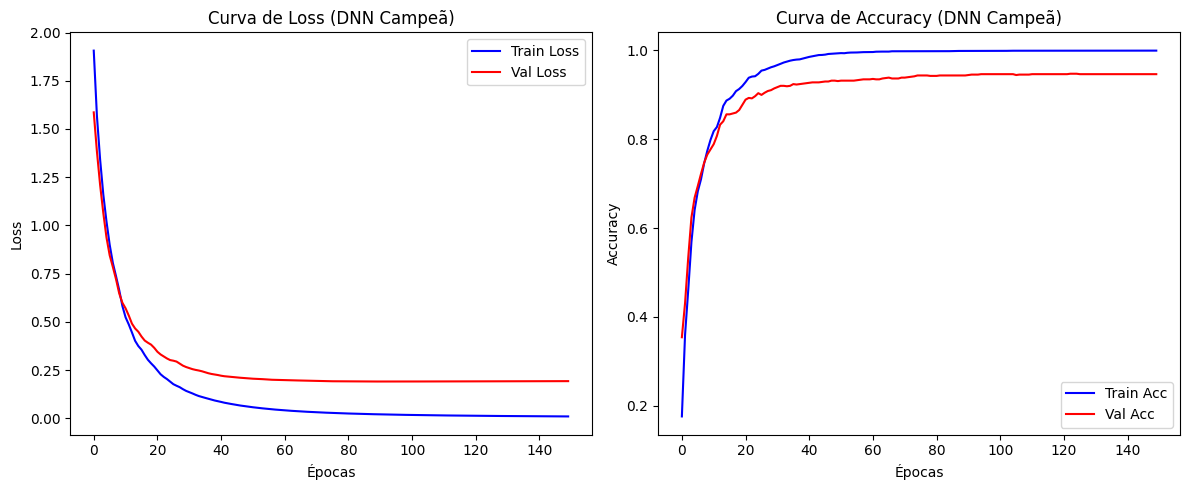


Relatório de Classificação Final (DNN Campeã):
              precision    recall  f1-score   support

   Anthropic       0.98      1.00      0.99       173
      Google       0.99      0.99      0.99       139
       Human       0.96      0.97      0.96       193
        Meta       0.93      0.92      0.92       155
     Mistral       0.91      0.89      0.90       184
      OpenAI       0.91      0.93      0.92       184

    accuracy                           0.95      1028
   macro avg       0.95      0.95      0.95      1028
weighted avg       0.95      0.95      0.95      1028



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("A treinar o Modelo DNN Final...")

bow_final = NumpyBagOfWords(max_words=3500)
X_train_final = bow_final.fit_transform(X_train)
X_val_final = bow_final.transform(X_val)

model_final = NeuralNetwork()
model_final.add(DenseLayer(input_size=3500, output_size=164))
model_final.add(ReLUActivation())
model_final.add(DenseLayer(input_size=164, output_size=num_classes))
model_final.add(SoftmaxActivation())

model_final.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=0.05))

history_final = model_final.fit(X_train_final, y_train_oh, epochs=150, val_data=(X_val_final, y_val_oh))

y_pred_final = np.argmax(model_final.forward(X_val_final, training=False), axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final['train_loss'], label='Train Loss', color='blue')
plt.plot(history_final['val_loss'], label='Val Loss', color='red')
plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final['train_acc'], label='Train Acc', color='blue')
plt.plot(history_final['val_acc'], label='Val Acc', color='red')
plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\nRelatório de Classificação Final:")
print(classification_report(y_val.values, y_pred_final, target_names=list(label_map.keys())))

model_final.save("../saved_models/DNN_final.pkl");
bow_final.save("../saved_models/DNN_bow_model.pkl")